# Aspect-Based Sentiment Analysis (ABSA) from Airbnb Reviews using Gemma3 and Ollama

This notebook extracts main aspects (topics) and their sentiments from Airbnb reviews using the Gemma3 model via Ollama API.
prompt claude haiku 3 miniutes.

PQ aucun sentiment n'est détecté ni de facet? peux tu améliorer le prompt et le reste

environ 20s par item. 

## 1. Import Required Libraries

In [34]:
import pandas as pd
import numpy as np
import requests
import json
import time
from tqdm import tqdm
import re
import warnings
warnings.filterwarnings('ignore')

# Set Ollama API endpoint
OLLAMA_API_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma3"

print(f"Ollama API endpoint: {OLLAMA_API_URL}")
print(f"Model: {MODEL_NAME}")

Ollama API endpoint: http://localhost:11434/api/generate
Model: gemma3


## 2. Check Ollama Connection

In [35]:
# Test Ollama connection
def test_ollama_connection():
    try:
        # Test with a simple prompt
        payload = {
            "model": MODEL_NAME,
            "prompt": "Say hello",
            "stream": False
        }
        response = requests.post(OLLAMA_API_URL, json=payload, timeout=10)
        if response.status_code == 200:
            print("✓ Ollama connection successful!")
            result = response.json()
            print(f"Response: {result.get('response', '')[:100]}")
            return True
        else:
            print(f"✗ Ollama connection failed: Status {response.status_code}")
            return False
    except Exception as e:
        print(f"✗ Error connecting to Ollama: {str(e)}")
        print("Make sure Ollama is running: ollama serve")
        return False

# Test connection
test_ollama_connection()

✗ Error connecting to Ollama: HTTPConnectionPool(host='localhost', port=11434): Read timed out. (read timeout=10)
Make sure Ollama is running: ollama serve


False

## 3. Load Reviews Data

In [36]:
# Load the same reviews data
reviews_df = pd.read_csv('./data/reviews_select.csv', nrows=5)

# Clean the data
reviews_df = reviews_df.dropna(subset=['comments'])
reviews_df['comments'] = reviews_df['comments'].astype(str)
reviews_df = reviews_df[reviews_df['comments'].str.strip() != '']
reviews_df = reviews_df.drop_duplicates(subset=['comments'])

print(f"Dataset shape: {reviews_df.shape}")
print(f"\nSample reviews:")
print(reviews_df['comments'].head(3).values)

Dataset shape: (5, 10)

Sample reviews:
['Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante sia situato in centro è molto silenzioso.'
 'Très bon emplacement pour cet appartement typique au cœur d une belle vie de quartier  tout en se préservant du calme. Hyper central pour visiter la capitale'
 'What a wonderful gem.  Great location, it was spotless and the studio was recently renovated. Even a new sofa bed.  We thoroughly enjoyed our stay and highly recommend.']


## 4. Define Helper Functions and Aspect-Based Sentiment Analysis Function

In [37]:
def parse_sentiment_value(sentiment_str):
    """Parse sentiment value from string"""
    try:
        # Try to extract a numerical value
        numbers = re.findall(r'[-+]?(?:\d*\.?\d+)', str(sentiment_str))
        if numbers:
            value = float(numbers[0])
            # Clamp to [-1, 1]
            return np.clip(value, -1.0, 1.0)
    except:
        pass

    # Try text-based sentiment
    sentiment_text = str(sentiment_str).lower()
    if any(word in sentiment_text for word in ['très positif', 'excellent', 'wonderful', '+1', 'très bien']):
        return 1.0
    elif any(word in sentiment_text for word in ['positif', 'bon', 'good', 'nice', 'well', '+0.5', 'très']):
        return 0.5
    elif any(word in sentiment_text for word in ['neutre', 'neutral', 'ok', '0', 'moyen']):
        return 0.0
    elif any(word in sentiment_text for word in ['négatif', 'bad', 'poor', 'mauvais', '-0.5']):
        return -0.5
    elif any(word in sentiment_text for word in ['très négatif', 'terrible', 'awful', 'horrible', '-1']):
        return -1.0

    return 0.0  # Default neutral

def parse_json_response(response_text, debug=False):
    """
    Parse JSON response with fallback strategies
    """
    if debug:
        print(f"Raw response: {response_text[:200]}...")

    # Strategy 1: Look for JSON object
    json_match = re.search(r'\{[^{}]*(?:\{[^{}]*\}[^{}]*)*\}', response_text, re.DOTALL)
    if json_match:
        try:
            json_str = json_match.group()
            json_data = json.loads(json_str)
            aspects_list = json_data.get('aspects', [])
            if aspects_list and debug:
                print(f"Successfully parsed JSON: {len(aspects_list)} aspects found")
            return aspects_list if aspects_list else []
        except json.JSONDecodeError as e:
            if debug:
                print(f"JSON parse error: {e}")
            pass

    # Strategy 2: Look for lines with "aspect/sentiment" pattern
    aspects_list = []
    lines = response_text.split('\n')
    for line in lines:
        # Look for patterns like "aspect_name: sentiment_value"
        if ':' in line and any(char in line for char in ['-', '+', '0', '1', '.']):
            parts = line.split(':')
            if len(parts) == 2:
                aspect_name = parts[0].strip().strip('-• * []()').strip()
                sentiment_str = parts[1].strip()

                # Clean aspect name
                aspect_name = re.sub(r'^[0-9]+\.\s*', '', aspect_name)  # Remove numbering

                if aspect_name and len(aspect_name) > 2:
                    sentiment_value = parse_sentiment_value(sentiment_str)
                    aspects_list.append({
                        'aspect': aspect_name,
                        'sentiment': sentiment_value
                    })

    if aspects_list and debug:
        print(f"Parsed {len(aspects_list)} aspects from text pattern")

    return aspects_list

def extract_aspects_with_sentiment(text, max_retries=3, debug=False):
    """
    Extract main aspects and their sentiments from a review using Gemma3 via Ollama

    Args:
        text: The review text
        max_retries: Number of retries if the request fails
        debug: Whether to print debug information

    Returns:
        List of dictionaries with 'aspect' and 'sentiment' keys
    """
    # Truncate text to reasonable length
    text = text[:600]

    prompt = f"""Tu es un expert en analyse d'avis clients. Analyse ce texte et identifie les principaux aspects/sujets mentionnés (jusqu'à 8 maximum).

Pour chaque aspect, donne un score de sentiment entre -1.0 et +1.0:
  -1.0 = très négatif, très critique
  -0.5 = négatif
   0.0 = neutre, ni positif ni négatif
  +0.5 = positif
  +1.0 = très positif, excellent

RÉPONDS TOUJOURS SOUS CETTE FORME EXACTEMENT:
{{
    "aspects": [
        {{"aspect": "nom aspect 1", "sentiment": 0.8}},
        {{"aspect": "nom aspect 2", "sentiment": -0.5}}
    ]
}}

Aspects possibles: localisation, location, commodités, amenities, propreté, cleanliness, confort, comfort, calme, quiet, communication, prix/value, qualité, host, réactivité, wifi, cuisine, kitchen, lit, bed, bruit, noise, spacieux, space, décoration, design, etc.

TEXTE À ANALYSER:
"{text}"

ANALYSE JSON (VALIDE):"""

    for attempt in range(max_retries):
        try:
            payload = {
                "model": MODEL_NAME,
                "prompt": prompt,
                "stream": False,
                "temperature": 0.3,  # Slightly higher for more diversity
                "top_p": 0.95,
                "num_predict": 250  # Limit output length
            }

            response = requests.post(OLLAMA_API_URL, json=payload, timeout=40)

            if response.status_code == 200:
                result = response.json()
                response_text = result.get('response', '').strip()

                if debug:
                    print(f"\n=== Debug Response ===")
                    print(f"Raw text: {response_text[:300]}")

                # Try to parse the response
                aspects_list = parse_json_response(response_text, debug=debug)

                if aspects_list:
                    return aspects_list
                else:
                    # If we still have no aspects after parsing, log it
                    if debug:
                        print(f"No aspects parsed from response")

                    if attempt < max_retries - 1:
                        time.sleep(1)
                        continue

            else:
                if debug:
                    print(f"HTTP Error {response.status_code}")
                if attempt < max_retries - 1:
                    time.sleep(2)
                    continue

        except requests.exceptions.Timeout:
            if debug:
                print(f"Timeout on attempt {attempt+1}")
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
        except Exception as e:
            if debug:
                print(f"Exception: {str(e)}")
            return []

    return []

# Test the function with a sample review WITH DEBUG
print("Testing aspect-based sentiment analysis with debug info...")
sample_review = reviews_df['comments'].iloc[0]
print(f"\nSample review: {sample_review[:150]}...")
print("\n" + "="*70)
aspects_sentiments = extract_aspects_with_sentiment(sample_review, debug=True)
print("="*70)
print(f"\nExtracted aspects with sentiments:")
if aspects_sentiments:
    for item in aspects_sentiments:
        print(f"  - {item.get('aspect', 'N/A')}: {item.get('sentiment', 'N/A')}")
else:
    print("  ⚠️ No aspects extracted - check debug output above!")

Testing aspect-based sentiment analysis with debug info...

Sample review: Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante sia situato in centro è molto silenzioso....


=== Debug Response ===
Raw text: ```json
{
    "aspects": [
        {"aspect": "confort", "sentiment": 0.9},
        {"aspect": "commodités", "sentiment": 0.8},
        {"aspect": "localisation", "sentiment": 0.6},
        {"aspect": "calme", "sentiment": 0.7},
        {"aspect": "propreté", "sentiment": 0.5},
        {"aspect": "d
Raw response: ```json
{
    "aspects": [
        {"aspect": "confort", "sentiment": 0.9},
        {"aspect": "commodités", "sentiment": 0.8},
        {"aspect": "localisation", "sentiment": 0.6},
        {"aspect":...
Successfully parsed JSON: 8 aspects found

Extracted aspects with sentiments:
  - confort: 0.9
  - commodités: 0.8
  - localisation: 0.6
  - calme: 0.7
  - propreté: 0.5
  - design: 0.4
  - cuisine: 0.2
  - espace: 0.3


## 5. Extract Aspects and Sentiments from All Reviews

In [38]:
# Extract aspects and sentiments from all reviews
print("Extracting aspects and sentiments from all reviews...")
print("This may take a while depending on the number of reviews...\n")

all_aspects_sentiments = []
reviews_list = reviews_df['comments'].tolist()
empty_count = 0

for i, review in enumerate(tqdm(reviews_list, desc="Analyzing reviews")):
    aspects_sentiments = extract_aspects_with_sentiment(review, debug=False)
    all_aspects_sentiments.append(aspects_sentiments)
    
    if not aspects_sentiments:
        empty_count += 1
    
    # Add a small delay to avoid overwhelming the API
    if (i + 1) % 3 == 0:
        time.sleep(0.5)

# Add aspects and sentiments to dataframe
reviews_df['aspects_sentiments'] = all_aspects_sentiments
reviews_df['aspects_count'] = reviews_df['aspects_sentiments'].apply(len)

print(f"\n✓ Analysis completed!")
print(f"  Reviews with aspects found: {len(reviews_df) - empty_count}/{len(reviews_df)}")
print(f"  Reviews with NO aspects: {empty_count}/{len(reviews_df)}")

print(f"\n📊 Sample results:")
for idx in range(min(5, len(reviews_df))):
    print(f"\n▶ Review {idx + 1}: {reviews_df['comments'].iloc[idx][:80]}...")
    aspects = reviews_df['aspects_sentiments'].iloc[idx]
    if aspects:
        for item in aspects:
            aspect = item.get('aspect', 'N/A')
            sentiment = item.get('sentiment', 'N/A')
            sentiment_label = "😊" if sentiment > 0.3 else "😞" if sentiment < -0.3 else "😐"
            print(f"    {sentiment_label} {aspect}: {sentiment}")
    else:
        print(f"    ⚠️ No aspects extracted")

Extracting aspects and sentiments from all reviews...
This may take a while depending on the number of reviews...



Analyzing reviews: 100%|██████████| 5/5 [01:46<00:00, 21.33s/it]


✓ Analysis completed!
  Reviews with aspects found: 5/5
  Reviews with NO aspects: 0/5

📊 Sample results:

▶ Review 1: Alloggio confortevole e pratico, dotato di tutto quello che serve. Nonostante si...
    😊 confort: 0.9
    😊 commodités: 0.8
    😊 localisation: 0.5
    😊 calme: 0.9
    😊 propreté: 0.5
    😊 design: 0.6
    😐 cuisine: 0.3
    😊 lit: 0.7

▶ Review 2: Très bon emplacement pour cet appartement typique au cœur d une belle vie de qua...
    😊 localisation: 0.9
    😊 emplacement: 0.8
    😊 calme: 0.7
    😊 centralité: 0.7
    😊 quartier: 0.6
    😊 confort: 0.6
    😊 design: 0.5
    😐 propreté: 0.3

▶ Review 3: What a wonderful gem.  Great location, it was spotless and the studio was recent...
    😊 localisation: 0.9
    😊 propreté: 0.9
    😊 renovations: 0.8
    😊 confort: 0.7
    😊 design: 0.6
    😊 prix/value: 0.5
    😊 hôte: 0.4
    😊 expérience générale: 0.9

▶ Review 4: We had a lovely 3 night stay.  Everything was just as described and they provide...
    😊 location:

## 6. Analyze Extracted Aspects and Sentiments

In [31]:
# Analyze aspects and sentiments
print("="*70)
print("ASPECT-BASED SENTIMENT ANALYSIS (ABSA)")
print("="*70)

# Overall statistics
print(f"\n📈 Overall Statistics:")
print(f"  Total reviews analyzed: {len(reviews_df)}")
print(f"  Average aspects per review: {reviews_df['aspects_count'].mean():.2f}")
print(f"  Max aspects in a review: {reviews_df['aspects_count'].max()}")
print(f"  Min aspects in a review: {reviews_df['aspects_count'].min()}")
print(f"  Total aspects extracted: {reviews_df['aspects_count'].sum()}")

# Collect all aspects with sentiments
all_aspects_data = []
aspect_sentiment_dict = {}

for aspects_sentiments in reviews_df['aspects_sentiments']:
    for item in aspects_sentiments:
        aspect_name = item.get('aspect', '').lower().strip()
        sentiment = item.get('sentiment', 0)
        
        # Validate sentiment is a number
        try:
            sentiment = float(sentiment)
        except (ValueError, TypeError):
            sentiment = 0.0
        
        if aspect_name:
            all_aspects_data.append({
                'aspect': aspect_name,
                'sentiment': sentiment
            })
            
            if aspect_name not in aspect_sentiment_dict:
                aspect_sentiment_dict[aspect_name] = []
            aspect_sentiment_dict[aspect_name].append(sentiment)

if not all_aspects_data:
    print("\n⚠️  WARNING: No aspects with sentiments were extracted!")
    print("This might indicate:")
    print("  - The model is not returning properly formatted JSON")
    print("  - The parsing logic needs adjustment")
    print("  - The prompting strategy needs improvement")
else:
    # Calculate statistics for each aspect
    aspect_stats = []
    for aspect, sentiments in aspect_sentiment_dict.items():
        sentiments = [float(s) for s in sentiments]  # Ensure all are floats
        aspect_stats.append({
            'aspect': aspect,
            'count': len(sentiments),
            'avg_sentiment': np.mean(sentiments),
            'min_sentiment': np.min(sentiments),
            'max_sentiment': np.max(sentiments),
            'std_sentiment': np.std(sentiments) if len(sentiments) > 1 else 0.0
        })

    aspect_stats_df = pd.DataFrame(aspect_stats).sort_values('count', ascending=False)

    print(f"\n\n📊 Top 15 Most Mentioned Aspects with Sentiment Analysis:")
    print("-" * 100)
    print(f"{'Aspect':<35} {'Count':<8} {'Avg Sentiment':<15} {'Min':<8} {'Max':<8} {'Std':<8}")
    print("-" * 100)

    for _, row in aspect_stats_df.head(15).iterrows():
        sentiment_icon = "😊" if row['avg_sentiment'] > 0.3 else "😞" if row['avg_sentiment'] < -0.3 else "😐"
        print(f"{sentiment_icon} {row['aspect']:<32} {row['count']:<8} {row['avg_sentiment']:>14.2f} {row['min_sentiment']:>7.2f} {row['max_sentiment']:>7.2f} {row['std_sentiment']:>7.2f}")

    print(f"\n\n📈 Sentiment Distribution Summary:")
    print(f"  Total unique aspects: {len(aspect_sentiment_dict)}")
    print(f"  Total aspect mentions: {len(all_aspects_data)}")
    if all_aspects_data:
        sentiments = [item['sentiment'] for item in all_aspects_data]
        sentiments = [float(s) for s in sentiments]
        print(f"  Overall average sentiment: {np.mean(sentiments):.3f}")
        print(f"  Overall sentiment std dev: {np.std(sentiments):.3f}")
        print(f"  Overall sentiment range: [{np.min(sentiments):.2f}, {np.max(sentiments):.2f}]")
        
        # Count positive, neutral, negative
        positive = sum(1 for s in sentiments if s > 0.3)
        neutral = sum(1 for s in sentiments if -0.3 <= s <= 0.3)
        negative = sum(1 for s in sentiments if s < -0.3)
        
        print(f"\n  Sentiment breakdown:")
        print(f"    😊 Positive (>0.3):  {positive} ({100*positive/len(sentiments):.1f}%)")
        print(f"    😐 Neutral (-0.3~0.3): {neutral} ({100*neutral/len(sentiments):.1f}%)")
        print(f"    😞 Negative (<-0.3):  {negative} ({100*negative/len(sentiments):.1f}%)")
        

ASPECT-BASED SENTIMENT ANALYSIS (ABSA)

📈 Overall Statistics:
  Total reviews analyzed: 100
  Average aspects per review: 7.93
  Max aspects in a review: 8
  Min aspects in a review: 1
  Total aspects extracted: 793


📊 Top 15 Most Mentioned Aspects with Sentiment Analysis:
----------------------------------------------------------------------------------------------------
Aspect                              Count    Avg Sentiment   Min      Max      Std     
----------------------------------------------------------------------------------------------------
😊 propreté                         80                 0.53   -0.60    0.90    0.28
😊 confort                          77                 0.68   -0.60    0.90    0.26
😊 prix/value                       77                 0.39   -0.30    0.90    0.27
😊 localisation                     74                 0.84    0.00    0.90    0.19
😊 communication                    50                 0.68   -0.20    0.90    0.24
😊 host              

## 7. Visualize Aspects and Sentiments

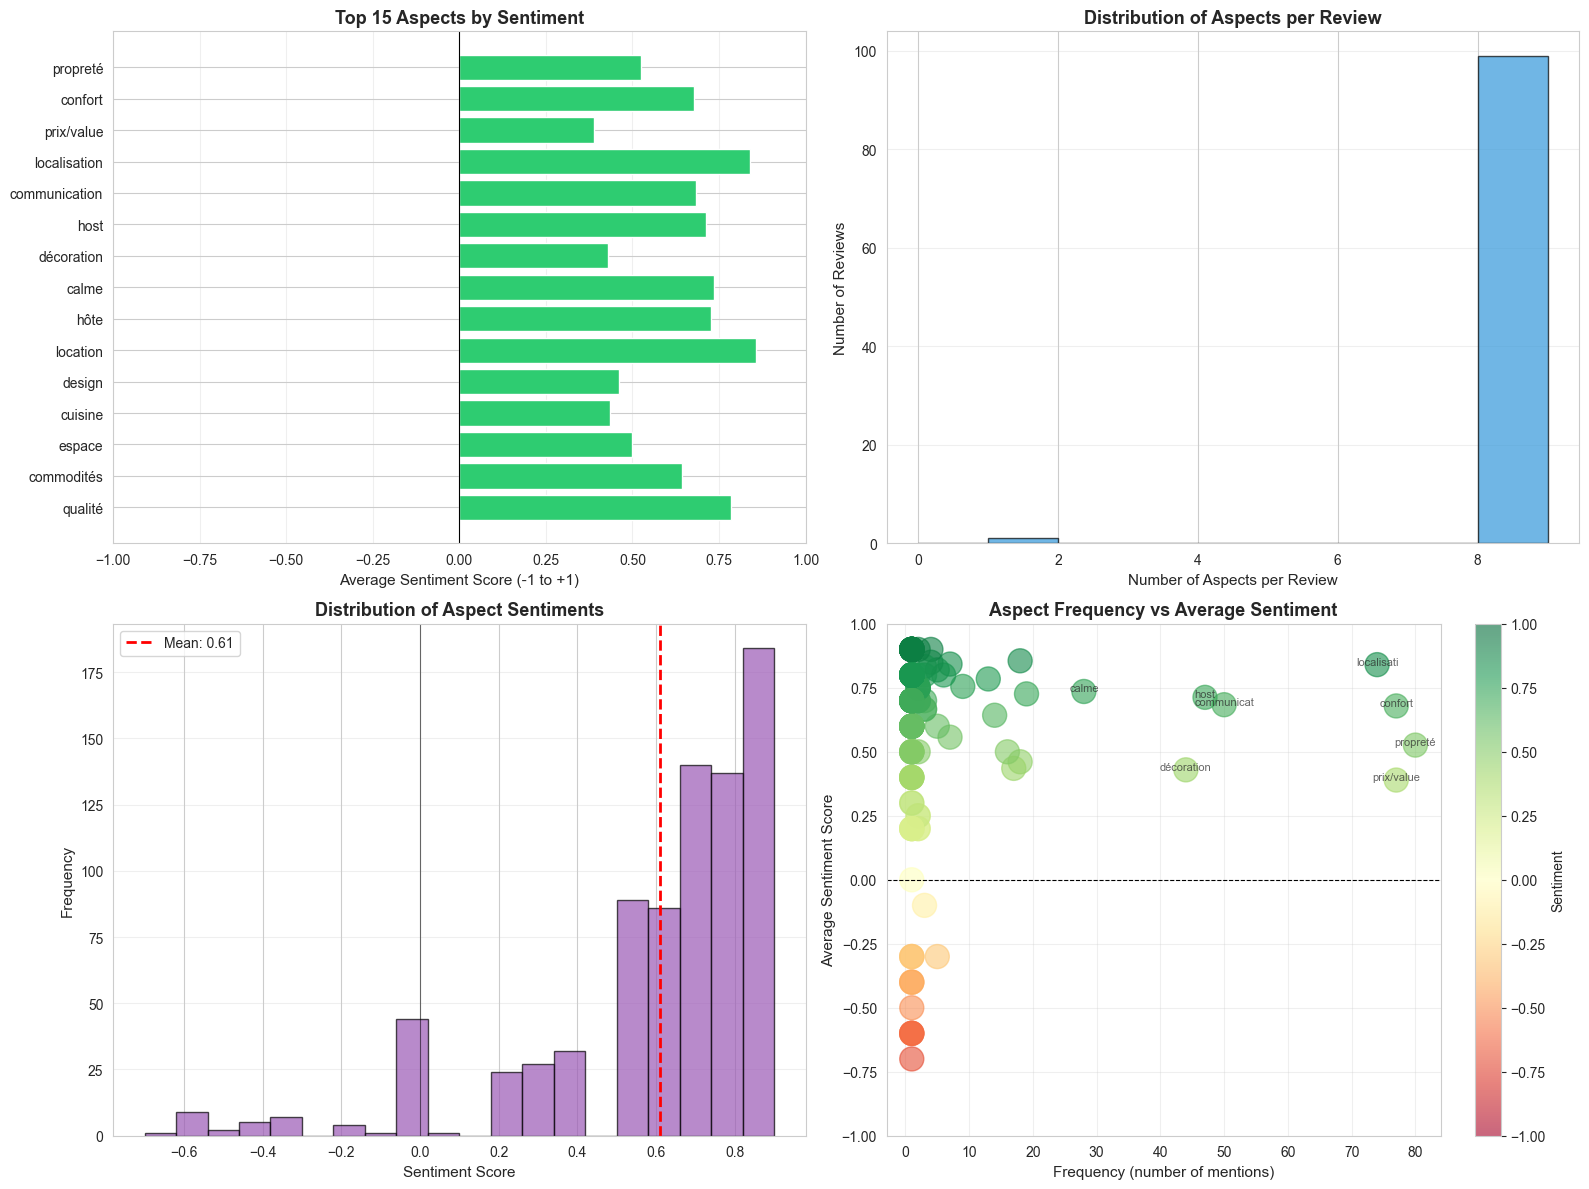

✓ Visualization completed!


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Check if we have data to visualize
if not aspect_stats_df.empty and len(all_aspects_data) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Top 15 Aspects with Average Sentiment (Bar Chart)
    top_15_aspects = aspect_stats_df.head(15)
    colors = ['#2ecc71' if x > 0.3 else '#e74c3c' if x < -0.3 else '#95a5a6' for x in top_15_aspects['avg_sentiment']]
    axes[0, 0].barh(top_15_aspects['aspect'], top_15_aspects['avg_sentiment'], color=colors)
    axes[0, 0].set_xlabel('Average Sentiment Score (-1 to +1)', fontsize=11)
    axes[0, 0].set_title('Top 15 Aspects by Sentiment', fontsize=13, fontweight='bold')
    axes[0, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[0, 0].set_xlim(-1, 1)
    axes[0, 0].invert_yaxis()
    axes[0, 0].grid(True, alpha=0.3, axis='x')

    # 2. Aspects per Review Distribution
    if reviews_df['aspects_count'].max() > 0:
        bins = range(0, int(reviews_df['aspects_count'].max()) + 2)
        axes[0, 1].hist(reviews_df['aspects_count'], bins=bins, color='#3498db', edgecolor='black', alpha=0.7)
        axes[0, 1].set_xlabel('Number of Aspects per Review', fontsize=11)
        axes[0, 1].set_ylabel('Number of Reviews', fontsize=11)
        axes[0, 1].set_title('Distribution of Aspects per Review', fontsize=13, fontweight='bold')
        axes[0, 1].grid(True, alpha=0.3, axis='y')

    # 3. Sentiment Distribution Across All Aspects
    all_sentiments = [item['sentiment'] for item in all_aspects_data]
    all_sentiments = [float(s) for s in all_sentiments]
    
    axes[1, 0].hist(all_sentiments, bins=20, color='#9b59b6', edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Sentiment Score', fontsize=11)
    axes[1, 0].set_ylabel('Frequency', fontsize=11)
    axes[1, 0].set_title('Distribution of Aspect Sentiments', fontsize=13, fontweight='bold')
    mean_sentiment = np.mean(all_sentiments)
    axes[1, 0].axvline(x=mean_sentiment, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_sentiment:.2f}')
    axes[1, 0].axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, axis='y')

    # 4. Scatter: Aspect Frequency vs Average Sentiment
    scatter = axes[1, 1].scatter(aspect_stats_df['count'], aspect_stats_df['avg_sentiment'], 
                                 s=300, alpha=0.6, c=aspect_stats_df['avg_sentiment'], cmap='RdYlGn', vmin=-1, vmax=1)
    axes[1, 1].set_xlabel('Frequency (number of mentions)', fontsize=11)
    axes[1, 1].set_ylabel('Average Sentiment Score', fontsize=11)
    axes[1, 1].set_title('Aspect Frequency vs Average Sentiment', fontsize=13, fontweight='bold')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    axes[1, 1].set_ylim(-1, 1)
    axes[1, 1].grid(True, alpha=0.3)
    cbar = plt.colorbar(scatter, ax=axes[1, 1])
    cbar.set_label('Sentiment', fontsize=10)
    
    # Add labels to scatter points for top aspects
    for _, row in aspect_stats_df.head(8).iterrows():
        axes[1, 1].annotate(row['aspect'][:10], 
                          (row['count'], row['avg_sentiment']),
                          fontsize=8, alpha=0.7, ha='center')

    plt.tight_layout()
    plt.show()
    print("✓ Visualization completed!")
    
else:
    print("\n⚠️  Cannot create visualizations - no aspects with sentiments were extracted.")
    print("Please check the debug output from the extraction step.")

## 8. Save Results to CSV

In [33]:
# Convert aspects list to string for CSV storage
def format_aspects_sentiments(aspects_sentiments):
    if not aspects_sentiments:
        return ''
    formatted = []
    for item in aspects_sentiments:
        aspect = item.get('aspect', 'N/A')
        sentiment = item.get('sentiment', 0)
        try:
            sentiment = float(sentiment)
            formatted.append(f"{aspect} ({sentiment:.2f})")
        except (ValueError, TypeError):
            formatted.append(f"{aspect} (N/A)")
    return ' | '.join(formatted) if formatted else ''

reviews_df['aspects_sentiments_string'] = reviews_df['aspects_sentiments'].apply(format_aspects_sentiments)

# Create output dataframe with relevant columns
output_df = reviews_df[['comments', 'aspects_sentiments_string', 'aspects_count']].copy()
output_df.columns = ['Review', 'Aspects_and_Sentiments', 'Aspect_Count']

# Save to CSV
output_filename = 'absa_results.csv'
output_df.to_csv(output_filename, index=False, encoding='utf-8')

print(f"✓ Results saved to: {output_filename}")
print(f"  Total records saved: {len(output_df)}")
print(f"  Reviews with aspects: {(output_df['Aspect_Count'] > 0).sum()}")
print(f"  Reviews without aspects: {(output_df['Aspect_Count'] == 0).sum()}")

# Also save aspect statistics with sentiments if we have data
if not aspect_stats_df.empty:
    aspect_stats_df.to_csv('absa_statistics.csv', index=False, encoding='utf-8')
    print(f"✓ Statistics saved to: absa_statistics.csv")
    print(f"  Unique aspects found: {len(aspect_stats_df)}")
else:
    print(f"⚠️  No aspect statistics to save (no sentiments extracted)")

print(f"\n📋 Preview of results (first 10 rows):")
print(output_df.head(10).to_string())

✓ Results saved to: absa_results.csv
  Total records saved: 100
  Reviews with aspects: 100
  Reviews without aspects: 0
✓ Statistics saved to: absa_statistics.csv
  Unique aspects found: 147

📋 Preview of results (first 10 rows):
                                                                                                                                                                                                                                                                                                                                                                                                                       Review                                                                                                                                                                               Aspects_and_Sentiments  Aspect_Count
0                                                                                                                                               